In [ ]:
# BiLSTM-based Intrusion Detection on TON IoT Dataset (Rewritten)

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, train_test_split

# Load Dataset
df = pd.read_csv('../dataset/final_df.csv', low_memory=False)
print("Original DataFrame Head:\n", df.head())
print("\nOriginal Class Distribution:\n", df['type'].value_counts())
print("\nOriginal Label Distribution:\n", df['label'].value_counts())
print("\nOriginal Data Types:\n", df.dtypes)
print("\nOriginal Data TShapesypes:\n", df.shape)

# --- Data Preprocessing ---
# Clean and impute
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna('Missing', inplace=True) # Or df[col].mode()[0]
        else:
            df[col].fillna(df[col].mean(), inplace=True)

print(f"Shape after handling NaNs: {df.shape}")

# Identify targets
TARGET_LABEL = 'label'
TARGET_TYPE = 'type'

# Encode categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if TARGET_TYPE in categorical_cols:
    categorical_cols.remove(TARGET_TYPE)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded column: {col}")

# Normalize numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if TARGET_LABEL in numerical_cols:
    numerical_cols.remove(TARGET_LABEL)

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Apply Min-Max Normalization for numerical features
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# For multi-class classification (specific attack types)
# You need to encode 'type' if you plan to use it as a multi-class target later
type_encoder = LabelEncoder()
y_multiclass_encoded = type_encoder.fit_transform(df[TARGET_TYPE])
# Convert to one-hot encoding for Keras if using categorical_crossentropy
y_multiclass_onehot = to_categorical(y_multiclass_encoded)

y_multiclass_labels = np.argmax(y_multiclass_onehot, axis=1)
print(f"Converted one-hot y_multiclass_onehot → labels with shape: {y_multiclass_labels.shape}")

binary_y = df[TARGET_LABEL].values
X = df.drop(columns=[TARGET_LABEL, TARGET_TYPE]).values

print("\nDataFrame dtypes after Preprocessing:\n", X.shape)


Original DataFrame Head:
            ts         src_ip  src_port        dst_ip  dst_port proto service  \
0  1556499101  192.168.1.193     60396  192.168.1.33      8080   tcp       -   
1  1556494424  192.168.1.193     59273  192.168.1.33      8080   tcp       -   
2  1556487945  192.168.1.193     57717  192.168.1.33      8080   tcp       -   
3  1556508616  192.168.1.193     62682  192.168.1.33        80   tcp       -   
4  1556511697  192.168.1.193     63419  192.168.1.33      8080   tcp       -   

   duration src_bytes  dst_bytes  ... http_response_body_len  \
0  0.000180         0          0  ...                      0   
1  0.000111         0          0  ...                      0   
2  0.000148         0          0  ...                      0   
3  0.000127         0          0  ...                      0   
4  0.000122         0          0  ...                      0   

   http_status_code  http_user_agent  http_orig_mime_types  \
0                 0                -          

In [4]:
# 1. Split BEFORE SMOTE (to avoid leakage)
# ----------------------------------------
X_train, X_test, y_train_binary, y_test_binary, \
y_train_multi, y_test_multi = train_test_split(
    X,
    binary_y,
    y_multiclass_labels,
    test_size=0.2,
    random_state=42,
    stratify=binary_y  # stratify on binary for this example
)

# Reset indices
X_train = pd.DataFrame(X_train).reset_index(drop=True).values
X_test = pd.DataFrame(X_test).reset_index(drop=True).values

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train_binary shape: {y_train_binary.shape}")
print(f"y_train_multiclass labels shape: {y_train_multi.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test_binary shape: {y_test_binary.shape}")
print(f"y_test_multiclass labels shape: {y_test_multi.shape}")


X_train shape: (352834, 44)
y_train_binary shape: (352834,)
y_train_multiclass labels shape: (352834,)
X_test  shape: (88209, 44)
y_test_binary shape: (88209,)
y_test_multiclass labels shape: (88209,)


In [5]:
print("\nClass distribution in y_train_binary:", Counter(y_train_binary))
print("Class distribution in y_test_binary:", Counter(y_test_binary))


Class distribution in y_train_binary: Counter({0: 240000, 1: 112834})
Class distribution in y_test_binary: Counter({0: 60000, 1: 28209})


In [ ]:
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.combine import SMOTEENN

print("before SMOTE:", Counter(y_train_binary))
smote = SMOTE(sampling_strategy={1:240000}, random_state=42)
X_train_binary_bal, y_train_binary_bal = smote.fit_resample(X_train, y_train_binary)
print("after SMOTE:", Counter(y_train_binary_bal))

print("SMOTENN Before:", Counter(y_train_binary))
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train_binary, verbose=True)
print("SMOTENN After:", Counter(y_resampled))

# ─── Cross‑Validation setup ────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─── RandomForest on SMOTE balance dataset ──────────────────────────────────────────────
randomForestSmoteClassifier = RandomForestClassifier(
    n_estimators=100,  # Instead of default 100-500
    max_depth=10,       # Limit depth
    min_samples_leaf=10,
    n_jobs=-1          # Parallelize training too
)
print("RandomForestClassifier", randomForestSmoteClassifier)

baseline_cv_scores = cross_val_score(
    randomForestSmoteClassifier, X_train_binary_bal, y_train_binary_bal,
    cv=cv, scoring='accuracy', n_jobs=1
)

print("RandomForestClassifier Baseline CV accuracy: mean={:.4f}, std={:.4f}".format(
    baseline_cv_scores.mean(), baseline_cv_scores.std()
))

# ─── Step 5b: Baseline fit + test evaluation ───────────────────────────────────
randomForestSmoteClassifier.fit(X_train_binary_bal, y_train_binary_bal)
y_pred_base = randomForestSmoteClassifier.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_base).ravel()
print("\nBaseline Test Performance:")
print(f" Accuracy : {accuracy_score(y_test_binary,y_pred_base):.4f}")
print(f" Recall   : {recall_score(y_test_binary,y_pred_base):.4f}")
print(f" Precision: {precision_score(y_test_binary,y_pred_base):.4f}")
print(f" FPR      : {fp/(fp+tn):.4f}")
print(f" FNR      : {fn/(fn+tp):.4f}")

# ─── RandomForest on SMOTENN balance dataset ──────────────────────────────────────────────
randomForestSmoteEnnClassifier = RandomForestClassifier(
    n_estimators=100,  # Instead of default 100-500
    max_depth=10,       # Limit depth
    min_samples_leaf=10,
    n_jobs=-1          # Parallelize training too
)
print("randomForestSmoteEnnClassifier", randomForestSmoteEnnClassifier)
baseline_cv_scores = cross_val_score(
    randomForestSmoteEnnClassifier, X_resampled, y_resampled,
    cv=cv, scoring='accuracy', n_jobs=1
)

print("randomForestSmoteEnnClassifier Baseline CV accuracy: mean={:.4f}, std={:.4f}".format(
    baseline_cv_scores.mean(), baseline_cv_scores.std()
))

# ─── Step 5b: Baseline fit + test evaluation ───────────────────────────────────
randomForestSmoteEnnClassifier.fit(X_resampled, y_resampled)
y_pred_base = randomForestSmoteEnnClassifier.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_base).ravel()
print("\nBaseline Test Performance:")
print(f" Accuracy : {accuracy_score(y_test_binary,y_pred_base):.4f}")
print(f" Recall   : {recall_score(y_test_binary,y_pred_base):.4f}")
print(f" Precision: {precision_score(y_test_binary,y_pred_base):.4f}")
print(f" FPR      : {fp/(fp+tn):.4f}")
print(f" FNR      : {fn/(fn+tp):.4f}")



Baseline model: RandomForestClassifier RandomForestClassifier(max_depth=10, min_samples_leaf=10, n_jobs=-1)
Baseline CV accuracy: mean=0.9994, std=0.0002

Baseline Test Performance:
 Accuracy : 0.9991
 Recall   : 0.9999
 Precision: 0.9973
 FPR      : 0.0013
 FNR      : 0.0001

Baseline model: randomForestSmoteEnnClassifier RandomForestClassifier(max_depth=10, min_samples_leaf=10, n_jobs=-1)
Baseline CV accuracy: mean=0.9993, std=0.0002

Baseline Test Performance:
 Accuracy : 0.9991
 Recall   : 0.9999
 Precision: 0.9974
 FPR      : 0.0012
 FNR      : 0.0001



Original class distribution: Counter({5: 240000, 3: 16075, 0: 16049, 7: 16043, 1: 15999, 6: 15960, 2: 15940, 8: 15935, 4: 833})

Applying SMOTE to multiclass training data...

✅ X_train_multi_bal shape: (153000, 44)
✅ y_train_multi_bal distribution:
0    17000
1    17000
2    17000
3    17000
4    17000
5    17000
6    17000
7    17000
8    17000
Name: count, dtype: int64

✅ y_train_multi_bal one-hot shape: (153000, 9)

Random Forest model on Balanced Multiclass Data
Accuracy on Test Set:  0.9978233513587049
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3951
           1       0.99      1.00      0.99      4001
           2       1.00      1.00      1.00      4060
           3       0.99      0.99      0.99      3925
           4       0.90      1.00      0.94       210
           5       1.00      1.00      1.00     60000
           6       0.99      1.00      1.00      4040
           7       1.00      

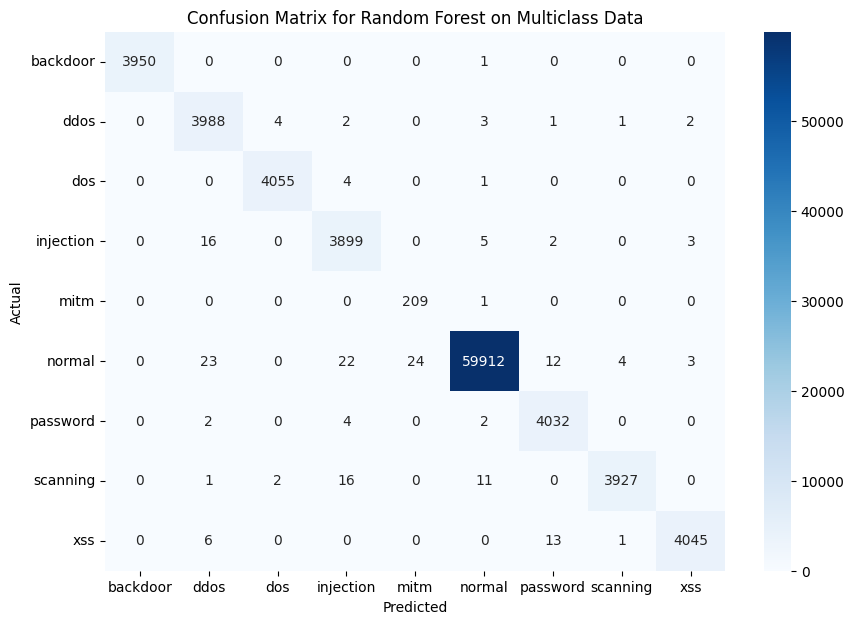


False Negative Rate (FNR) per class:
Class 0: 0.0003
Class 1: 0.0032
Class 2: 0.0012
Class 3: 0.0066
Class 4: 0.0048
Class 5: 0.0015
Class 6: 0.002
Class 7: 0.0076
Class 8: 0.0049

False Positive Rate (FPR) per class:
Class 0: 0.0
Class 1: 0.0006
Class 2: 0.0001
Class 3: 0.0006
Class 4: 0.0003
Class 5: 0.0009
Class 6: 0.0003
Class 7: 0.0001
Class 8: 0.0001


In [ ]:
from collections import Counter
from sklearn.preprocessing import OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_fnr_fpr(cm):
    fnr_per_class = {}
    fpr_per_class = {}

    n_classes = cm.shape[0]
    for i in range(n_classes):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        # Avoid division by zero
        FNR = FN / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        fnr_per_class[i] = round(FNR, 4)
        fpr_per_class[i] = round(FPR, 4)

    return fnr_per_class, fpr_per_class

# 1. Check class distribution before balancing
print("\nOriginal class distribution:", Counter(y_train_multi))

# 2. Downsample majority class (class 5)
# under_sampler = RandomUnderSampler(
#     sampling_strategy={5: 17000},  # reduce class 5
#     random_state=42
# )
# X_under, y_under = under_sampler.fit_resample(X_train, y_train_multi)
# print("\nAfter undersampling class 5:", Counter(y_under))

# 3. Apply SMOTE to minority classes (bring all to 17k)
smote_multi = SMOTE(
    sampling_strategy={
        0: 17000,
        1: 17000,
        2: 17000,
        3: 17000,
        4: 17000,
        6: 17000,
        7: 17000,
        8: 17000
        # class 5 is already 17000 if using RandomUnderSampler otherwise 240000
    },
    random_state=42
)

print("\nApplying SMOTE to multiclass training data...")
X_train_multi_bal, y_train_multi_bal = smote_multi.fit_resample(X_under, y_under)

print(f"\n✅ X_train_multi_bal shape: {X_train_multi_bal.shape}")
print("✅ y_train_multi_bal distribution:")
print(pd.Series(y_train_multi_bal).value_counts())

# 4. Convert balanced multiclass labels to one‑hot
ohe = OneHotEncoder(sparse_output=False, categories='auto')  # for scikit-learn >=1.4
y_train_multi_bal_ohe = ohe.fit_transform(y_train_multi_bal.reshape(-1, 1))
print(f"\n✅ y_train_multi_bal one-hot shape: {y_train_multi_bal_ohe.shape}")


# Train Random Forest on Balanced Multiclass Data
# -------------------------------------------------
# y_train_multi, y_test_multi
print("\nRandom Forest model on Balanced Multiclass Data")
base_rf_multi = RandomForestClassifier(
    n_estimators=100,  # Instead of default 100-500
    max_depth=10,       # Limit depth
    min_samples_leaf=10,
    n_jobs=-1          # Parallelize training too
)
base_rf_multi.fit(X_train_multi_bal, y_train_multi_bal)
# Evaluate on Test Set
print("Accuracy on Test Set: ", base_rf_multi.score(X_test, y_test_multi))
# Baseline test evaluation
y_pred_base_multi = base_rf_multi.predict(X_test)
print("Classification Report:")
print(classification_report(y_test_multi, y_pred_base_multi))
print("Confusion Matrix:")
multiclass_cm = confusion_matrix(y_test_multi, y_pred_base_multi)

print(multiclass_cm)
print("Matthews Correlation Coefficient:", matthews_corrcoef(y_test_multi, y_pred_base_multi))
print("ROC AUC Score:", roc_auc_score(y_test_multi, base_rf_multi.predict_proba(X_test), multi_class='ovr'))

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test_multi, y_pred_base_multi), annot=True, fmt='d', cmap='Blues',
            xticklabels=type_encoder.classes_, yticklabels=type_encoder.classes_)
plt.title('Confusion Matrix for Random Forest on Multiclass Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Compute FNR and FPR
fnr, fpr = calculate_fnr_fpr(multiclass_cm)

# Display Results
print("\nFalse Negative Rate (FNR) per class:")
for cls, rate in fnr.items():
    print(f"Class {cls}: {rate}")

print("\nFalse Positive Rate (FPR) per class:")
for cls, rate in fpr.items():
    print(f"Class {cls}: {rate}")
